# Stenosis Localization With Mask R-CNN

This notebook trains a Mask R-CNN model to localize stenosis regions in coronary angiography frames.
It uses the existing COCO `bbox` and `segmentation` annotations from `data/stenosis` and predicts both:
- a bounding box around stenosis
- a pixel mask over the stenosis region

The earlier classifier-style workflow answered only whether stenosis was present. This version learns where stenosis is.


In [ ]:
# --- Imports and settings ---
from collections import Counter
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader


NUM_WORKERS = 0
STENOSIS_CATEGORY_ID = 26


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


print('Device:', device)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())


Device: cuda
2.5.1+cu121
12.1
True


In [3]:


print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


2.5.1+cu121
True
1
NVIDIA GeForce RTX 4060 Laptop GPU


## Data Loading (COCO)

This section reads the COCO annotations and prepares split-level metadata for both the `syntax` and `stenosis` datasets.


In [4]:
def resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here] + list(here.parents):
        if (candidate / 'data').exists():
            return candidate
        if (candidate / 'archive' / 'data').exists():
            return candidate / 'archive'
    return here


project_root = resolve_project_root()


def get_split_paths(root: Path, dataset_name: str, split: str):
    img_dir = root / 'data' / dataset_name / split / 'images'
    ann_path = root / 'data' / dataset_name / split / 'annotations' / f'{split}.json'
    return img_dir, ann_path


def load_coco_json(json_path: Path):
    with open(json_path, 'r', encoding='utf-8') as f:
        return json.load(f)


def build_image_lookup(coco_data):
    return {item['id']: item['file_name'] for item in coco_data['images']}


def build_annotations_lookup(coco_data):
    anns_lookup = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        anns_lookup.setdefault(img_id, []).append(ann)
    return anns_lookup


def load_dataset_split(dataset_name: str, split_name: str):
    img_dir, ann_path = get_split_paths(project_root, dataset_name, split_name)
    coco = load_coco_json(ann_path)
    return {
        'dataset': dataset_name,
        'split': split_name,
        'img_dir': img_dir,
        'coco': coco,
        'image_lookup': build_image_lookup(coco),
        'anns_lookup': build_annotations_lookup(coco),
    }


stenosis_splits = {s: load_dataset_split('stenosis', s) for s in ['train', 'val', 'test']}
syntax_splits = {s: load_dataset_split('syntax', s) for s in ['train', 'val', 'test']}


# Keep this alias so the later stenosis-specific detection cells still work.
splits = stenosis_splits


train_categories = {c['id']: c['name'] for c in stenosis_splits['train']['coco'].get('categories', [])}
syntax_categories = {c['id']: c['name'] for c in syntax_splits['train']['coco'].get('categories', [])}
print('Stenosis categories:', train_categories)
print('Syntax categories:', syntax_categories)
if STENOSIS_CATEGORY_ID not in train_categories:
    raise ValueError(f"Stenosis category_id {STENOSIS_CATEGORY_ID} not found in categories.")


Stenosis categories: {1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '9a', 11: '10', 12: '10a', 13: '11', 14: '12', 15: '12a', 16: '13', 17: '14', 18: '14a', 19: '15', 20: '16', 21: '16a', 22: '16b', 23: '16c', 24: '12b', 25: '14b', 26: 'stenosis'}
Syntax categories: {1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '9a', 11: '10', 12: '10a', 13: '11', 14: '12', 15: '12a', 16: '13', 17: '14', 18: '14a', 19: '15', 20: '16', 21: '16a', 22: '16b', 23: '16c', 24: '12b', 25: '14b', 26: 'stenosis'}


## EDA (Exploratory Data Analysis)

What we check here:
- Class distribution for `syntax` and `stenosis`
- Missing image files
- Sample images and stenosis overlays
- Class imbalance notes for both datasets


Stenosis split stats


,split,total_images,stenosis_images,non_stenosis_images,stenosis_annotations,all_annotations,missing_images,positive_rate
0,train,1000,997,3,1625,1625,0,0.997
1,val,200,200,0,406,406,0,1.000
2,test,300,300,0,386,386,0,1.000


Syntax split stats


,split,total_images,stenosis_images,non_stenosis_images,stenosis_annotations,all_annotations,missing_images,positive_rate
0,train,1000,0,1000,0,4976,0,0.0
1,val,200,0,200,0,1168,0,0.0
2,test,300,0,300,0,1672,0,0.0


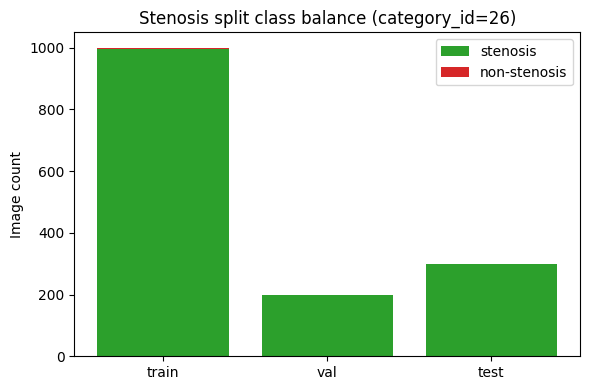

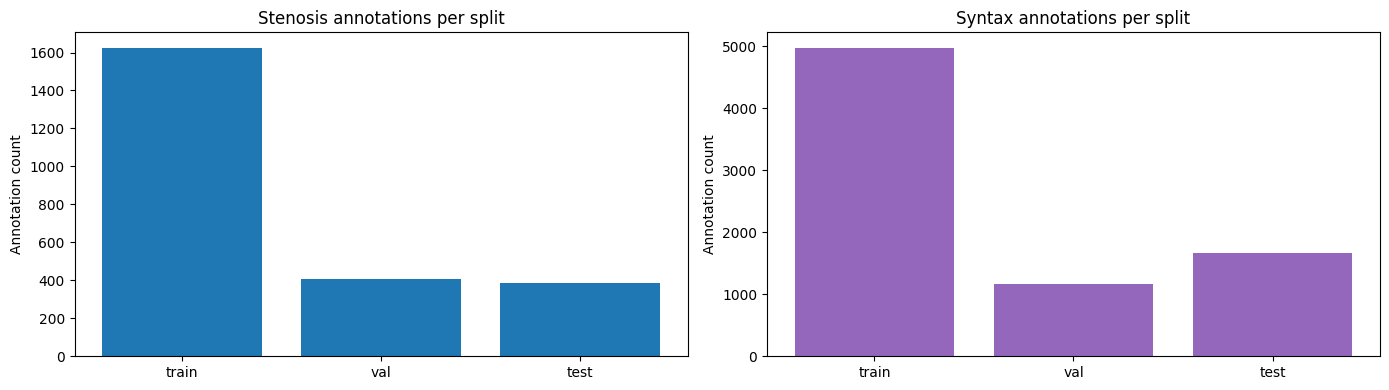

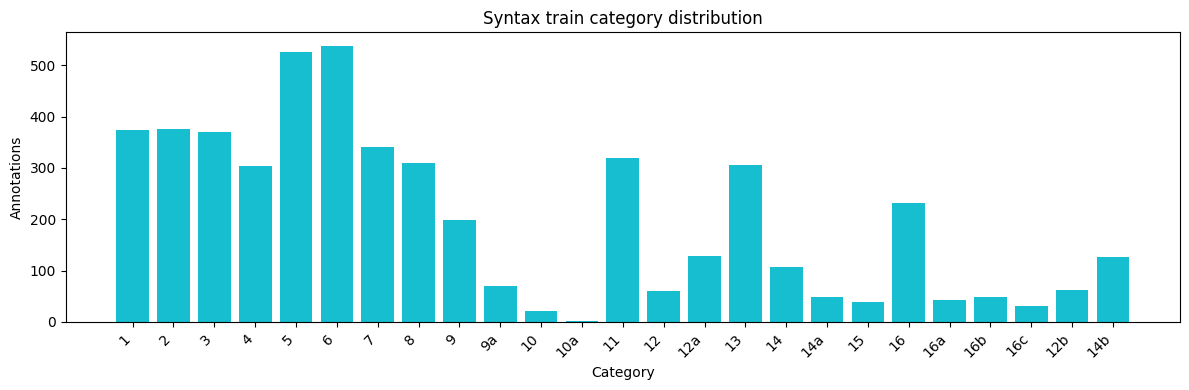

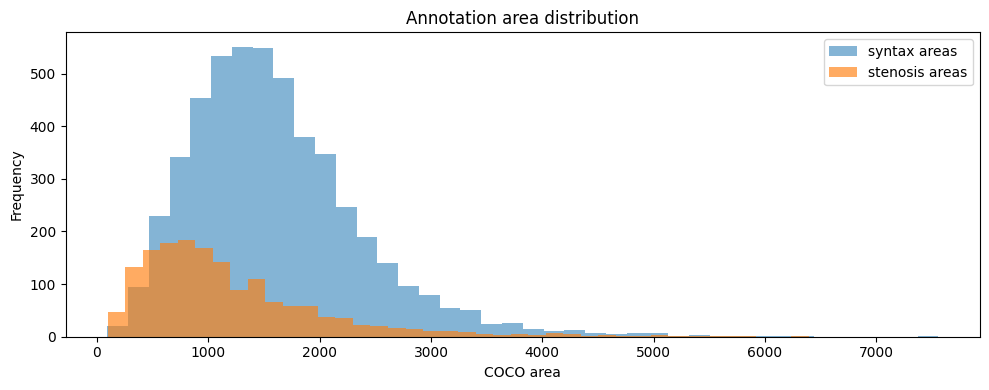

In [5]:
def summarize_split(dataset_splits, split_name):
    info = dataset_splits[split_name]
    images = info['coco']['images']
    annotations = info['coco']['annotations']
    img_dir = info['img_dir']
    image_lookup = info['image_lookup']

    missing_files = []
    for image in images:
        image_path = img_dir / image_lookup[image['id']]
        if not image_path.exists():
            missing_files.append(str(image_path))

    stenosis_anns = [ann for ann in annotations if ann.get('category_id') == STENOSIS_CATEGORY_ID]
    stenosis_image_ids = {ann['image_id'] for ann in stenosis_anns}

    total_images = len(images)
    positive_images = len(stenosis_image_ids)
    negative_images = total_images - positive_images

    return {
        'split': split_name,
        'total_images': total_images,
        'stenosis_images': positive_images,
        'non_stenosis_images': negative_images,
        'stenosis_annotations': len(stenosis_anns),
        'all_annotations': len(annotations),
        'missing_images': len(missing_files),
        'positive_rate': positive_images / max(total_images, 1),
        'missing_examples': missing_files[:5],
    }


stenosis_split_rows = [summarize_split(stenosis_splits, s) for s in ['train', 'val', 'test']]
syntax_split_rows = [summarize_split(syntax_splits, s) for s in ['train', 'val', 'test']]
stenosis_split_stats = pd.DataFrame(stenosis_split_rows).drop(columns=['missing_examples'])
syntax_split_stats = pd.DataFrame(syntax_split_rows).drop(columns=['missing_examples'])

print('Stenosis split stats')
display(stenosis_split_stats)
print('Syntax split stats')
display(syntax_split_stats)

for row in stenosis_split_rows:
    if row['missing_images'] > 0:
        print(f"Missing files in {row['split']}: {row['missing_images']} (examples: {row['missing_examples']})")
    if row['stenosis_images'] == 0 or row['non_stenosis_images'] == 0:
        print(
            f"Warning: {row['split']} has stenosis_images={row['stenosis_images']}, "
            f"non_stenosis_images={row['non_stenosis_images']}. AUC may be undefined."
        )

plt.figure(figsize=(6, 4))
plt.bar(stenosis_split_stats['split'], stenosis_split_stats['stenosis_images'], label='stenosis', color='#2ca02c')
plt.bar(
    stenosis_split_stats['split'],
    stenosis_split_stats['non_stenosis_images'],
    bottom=stenosis_split_stats['stenosis_images'],
    label='non-stenosis',
    color='#d62728',
)
plt.title('Stenosis split class balance (category_id=26)')
plt.ylabel('Image count')
plt.legend()
plt.tight_layout()
plt.show()


# Extra EDA plots for localization training
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(stenosis_split_stats['split'], stenosis_split_stats['all_annotations'], color='#1f77b4')
axes[0].set_title('Stenosis annotations per split')
axes[0].set_ylabel('Annotation count')
axes[1].bar(syntax_split_stats['split'], syntax_split_stats['all_annotations'], color='#9467bd')
axes[1].set_title('Syntax annotations per split')
axes[1].set_ylabel('Annotation count')
plt.tight_layout()
plt.show()

syntax_train_categories = pd.Series([
    ann['category_id'] for ann in syntax_splits['train']['coco']['annotations']
]).value_counts().sort_index()
syntax_train_category_names = [syntax_categories.get(int(cid), str(cid)) for cid in syntax_train_categories.index]
plt.figure(figsize=(12, 4))
plt.bar(syntax_train_category_names, syntax_train_categories.values, color='#17becf')
plt.title('Syntax train category distribution')
plt.xlabel('Category')
plt.ylabel('Annotations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

stenosis_train_areas = [ann.get('area', 0) for ann in stenosis_splits['train']['coco']['annotations'] if ann.get('category_id') == STENOSIS_CATEGORY_ID]
syntax_train_areas = [ann.get('area', 0) for ann in syntax_splits['train']['coco']['annotations']]
plt.figure(figsize=(10, 4))
plt.hist(syntax_train_areas, bins=40, alpha=0.55, label='syntax areas')
plt.hist(stenosis_train_areas, bins=40, alpha=0.65, label='stenosis areas')
plt.title('Annotation area distribution')
plt.xlabel('COCO area')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


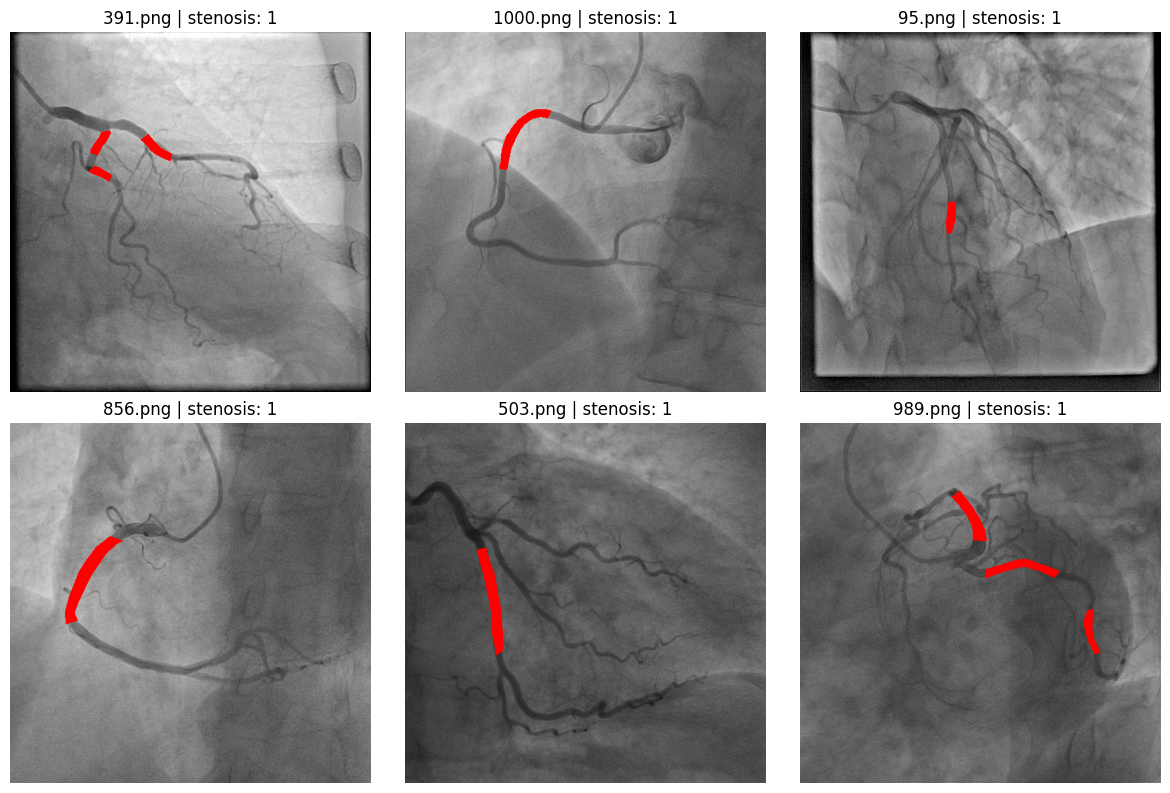

In [ ]:
def polygons_to_mask(annotations, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    for ann in annotations:
        seg = ann.get('segmentation', [])
        if not isinstance(seg, list):
            continue
        for poly in seg:
            pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
            pts = np.round(pts).astype(np.int32)
            if pts.shape[0] >= 3:
                cv2.fillPoly(mask, [pts], 1)
    return mask


def show_sample_images(split_name='train', sample_count=6):
    info = splits[split_name]
    images = info['coco']['images']
    img_dir = info['img_dir']
    image_lookup = info['image_lookup']
    anns_lookup = info['anns_lookup']

    sample_count = min(sample_count, len(images))
    samples = random.sample(images, sample_count)

    cols = 3
    rows = int(np.ceil(sample_count / cols))
    plt.figure(figsize=(12, 4 * rows))

    for idx, image_info in enumerate(samples, start=1):
        image_id = image_info['id']
        image_path = img_dir / image_lookup[image_id]
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue
        anns = anns_lookup.get(image_id, [])
        stenosis_anns = [ann for ann in anns if ann.get('category_id') == STENOSIS_CATEGORY_ID]
        mask = polygons_to_mask(stenosis_anns, image.shape[0], image.shape[1])
        overlay = image.copy()
        overlay = cv2.cvtColor(overlay, cv2.COLOR_GRAY2RGB)
        overlay[mask == 1] = [255, 0, 0]
        for ann in stenosis_anns:
            x, y, w, h = [float(v) for v in ann.get('bbox', [0, 0, 0, 0])]
            x1, y1 = int(round(x)), int(round(y))
            x2, y2 = int(round(x + w)), int(round(y + h))
            cv2.rectangle(overlay, (x1, y1), (x2, y2), [255, 255, 0], 2)

        plt.subplot(rows, cols, idx)
        plt.imshow(overlay)
        plt.title(f"{image_path.name} | stenosis: {int(mask.sum() > 0)}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


show_sample_images('train', sample_count=6)


## Preprocessing and Localization Datasets

These datasets convert COCO annotations into TorchVision Mask R-CNN targets.
- `syntax` is used first for anatomy/artery segment pretraining.
- `stenosis` is then fine-tuned as a binary localization task: background + stenosis.


Syntax sample: C:\Users\kdkav\Desktop\sorter\rishav\archive\data\syntax\train\images\922.png (3, 512, 512) torch.Size([4, 4]) torch.Size([4, 512, 512]) labels: [8, 6, 5, 7]
Stenosis sample: C:\Users\kdkav\Desktop\sorter\rishav\archive\data\stenosis\train\images\676.png (3, 512, 512) torch.Size([1, 4]) torch.Size([1, 512, 512]) labels: [1]


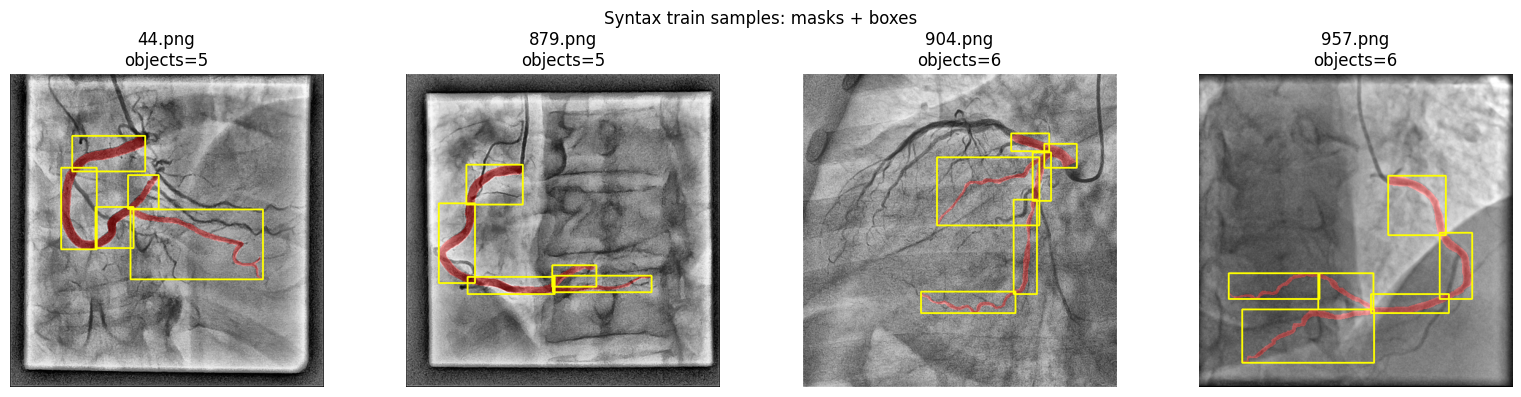

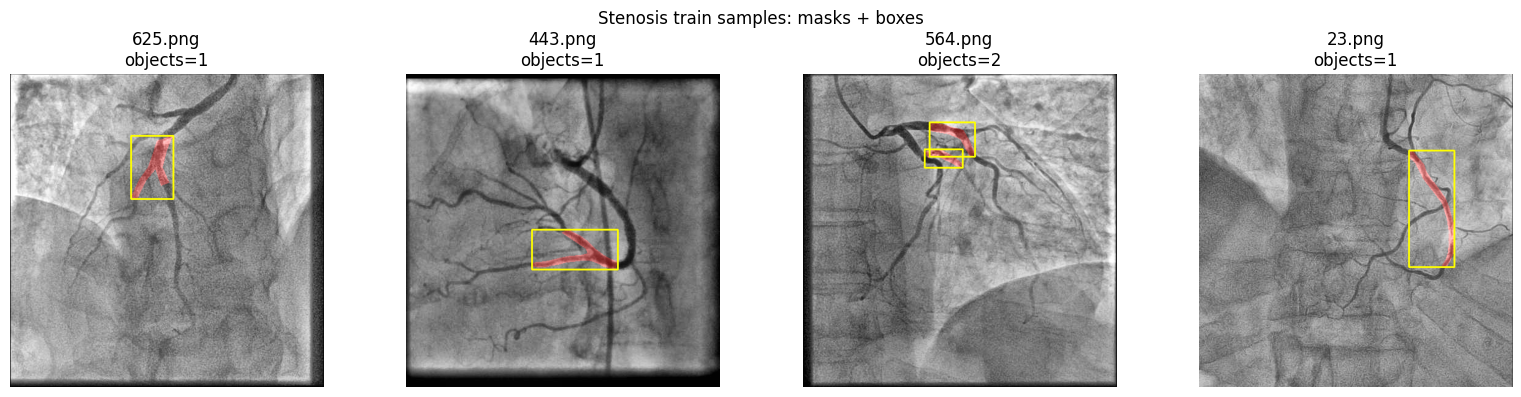

In [7]:
from torchvision.transforms import functional as F

TRAINING_PROFILE = 'full'  # full training mode
MASKRCNN_BATCH_SIZE = 2 if torch.cuda.is_available() else 1
MASKRCNN_SYNTAX_EPOCHS = 5      # syntax anatomy pretraining
MASKRCNN_STENOSIS_EPOCHS = 15   # stenosis fine-tuning
MASKRCNN_LR = 1e-4
MASKRCNN_WEIGHT_DECAY = 1e-4
MASKRCNN_SCORE_THRESHOLD = 0.5
MASKRCNN_MAX_SYNTAX_TRAIN_BATCHES = None  # None = full syntax train split
MASKRCNN_MAX_SYNTAX_VAL_BATCHES = None    # None = full syntax val split
MASKRCNN_MAX_TRAIN_BATCHES = None         # None = full stenosis train split
MASKRCNN_MAX_VAL_BATCHES = None           # None = full stenosis val split
USE_COCO_PRETRAINED_MASKRCNN = True       # best if cached/internet works; falls back if unavailable
RESUME_FROM_CHECKPOINTS = True            # continue from latest checkpoints if present
CHECKPOINT_DIR = project_root / 'runs' / 'stenosis_localizer'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

SYNTAX_NUM_CLASSES = max(syntax_categories) + 1      # background 0 + category ids 1..26
STENOSIS_NUM_CLASSES = 2                             # background 0 + stenosis 1


def apply_clahe(gray_image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray_image)


def collate_fn(batch):
    return tuple(zip(*batch))


class CocoMaskDataset(Dataset):
    def __init__(self, dataset_splits, split_name, train=False, use_clahe=True, stenosis_only=False):
        self.split = split_name
        self.train = train
        self.use_clahe = use_clahe
        self.stenosis_only = stenosis_only
        self.info = dataset_splits[split_name]
        self.coco = self.info['coco']
        self.img_dir = self.info['img_dir']
        self.image_lookup = self.info['image_lookup']
        self.anns_lookup = self.info['anns_lookup']
        self.images = self.coco['images']

    def __len__(self):
        return len(self.images)

    def annotation_to_label(self, ann):
        if self.stenosis_only:
            return 1 if ann.get('category_id') == STENOSIS_CATEGORY_ID else None
        return int(ann.get('category_id'))

    def __getitem__(self, index):
        image_info = self.images[index]
        image_id = int(image_info['id'])
        image_path = self.img_dir / self.image_lookup[image_id]

        gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            raise FileNotFoundError(image_path)
        if self.use_clahe:
            gray = apply_clahe(gray)

        height, width = gray.shape[:2]
        rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        anns = self.anns_lookup.get(image_id, [])

        boxes = []
        masks = []
        labels = []
        areas = []
        for ann in anns:
            label = self.annotation_to_label(ann)
            if label is None:
                continue
            x, y, w, h = [float(v) for v in ann.get('bbox', [0, 0, 0, 0])]
            if w <= 1 or h <= 1:
                continue
            mask = polygons_to_mask([ann], height, width)
            if int(mask.sum()) == 0:
                continue
            boxes.append([x, y, x + w, y + h])
            masks.append(mask)
            labels.append(label)
            areas.append(float(ann.get('area', mask.sum())))

        if self.train and random.random() < 0.5:
            rgb = np.ascontiguousarray(rgb[:, ::-1])
            masks = [np.ascontiguousarray(mask[:, ::-1]) for mask in masks]
            boxes = [[width - x2, y1, width - x1, y2] for x1, y1, x2, y2 in boxes]

        num_objects = len(boxes)
        image = F.to_tensor(Image.fromarray(rgb))
        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32).reshape(num_objects, 4),
            'labels': torch.as_tensor(labels, dtype=torch.int64),
            'masks': torch.as_tensor(np.stack(masks), dtype=torch.uint8) if masks else torch.zeros((0, height, width), dtype=torch.uint8),
            'image_id': torch.tensor([image_id], dtype=torch.int64),
            'area': torch.as_tensor(areas, dtype=torch.float32),
            'iscrowd': torch.zeros((num_objects,), dtype=torch.int64),
        }
        return image, target, str(image_path)


syntax_train_dataset = CocoMaskDataset(syntax_splits, 'train', train=True, use_clahe=True, stenosis_only=False)
syntax_val_dataset = CocoMaskDataset(syntax_splits, 'val', train=False, use_clahe=True, stenosis_only=False)
train_dataset = CocoMaskDataset(stenosis_splits, 'train', train=True, use_clahe=True, stenosis_only=True)
val_dataset = CocoMaskDataset(stenosis_splits, 'val', train=False, use_clahe=True, stenosis_only=True)
test_dataset = CocoMaskDataset(stenosis_splits, 'test', train=False, use_clahe=True, stenosis_only=True)

syntax_train_loader = DataLoader(syntax_train_dataset, batch_size=MASKRCNN_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
syntax_val_loader = DataLoader(syntax_val_dataset, batch_size=MASKRCNN_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
train_loader = DataLoader(train_dataset, batch_size=MASKRCNN_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=MASKRCNN_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

syntax_sample_image, syntax_sample_target, syntax_sample_path = syntax_train_dataset[0]
sample_image, sample_target, sample_path = train_dataset[0]
print('Syntax sample:', syntax_sample_path, tuple(syntax_sample_image.shape), syntax_sample_target['boxes'].shape, syntax_sample_target['masks'].shape, 'labels:', syntax_sample_target['labels'][:5].tolist())
print('Stenosis sample:', sample_path, tuple(sample_image.shape), sample_target['boxes'].shape, sample_target['masks'].shape, 'labels:', sample_target['labels'].tolist())



def show_dataset_samples(dataset, title, sample_count=4, seed=42):
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), min(sample_count, len(dataset)))
    cols = len(indices)
    plt.figure(figsize=(4 * cols, 4))
    for plot_idx, dataset_idx in enumerate(indices, start=1):
        image_tensor, target, image_path = dataset[dataset_idx]
        rgb = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
        rgb = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
        overlay = rgb.copy()
        for mask in target['masks']:
            mask_np = mask.detach().cpu().numpy().astype(bool)
            color_layer = np.zeros_like(overlay)
            color_layer[mask_np] = [255, 0, 0]
            overlay = cv2.addWeighted(overlay, 1.0, color_layer, 0.35, 0)
        for box in target['boxes'].detach().cpu().numpy():
            x1, y1, x2, y2 = [int(round(v)) for v in box]
            cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 255, 0), 2)
        plt.subplot(1, cols, plot_idx)
        plt.imshow(overlay)
        plt.title(f"{Path(image_path).name}\nobjects={len(target['boxes'])}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_dataset_samples(syntax_train_dataset, 'Syntax train samples: masks + boxes', sample_count=4, seed=1)
show_dataset_samples(train_dataset, 'Stenosis train samples: masks + boxes', sample_count=4, seed=2)


## Mask R-CNN ResNet50-FPN Model

The model uses TorchVision's ResNet50-FPN Mask R-CNN. If COCO weights are available, they are used first; otherwise the notebook falls back cleanly and still pretrains on `syntax` before stenosis fine-tuning.


In [8]:
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights, maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


def replace_maskrcnn_heads(model, num_classes):
    box_in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(box_in_features, num_classes)

    mask_in_features = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(mask_in_features, hidden_layer, num_classes)
    return model


def build_maskrcnn_model(num_classes, use_coco_pretrained=False):
    weights = None
    if use_coco_pretrained:
        try:
            weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
            model = maskrcnn_resnet50_fpn(weights=weights, min_size=512, max_size=512)
            print('Loaded TorchVision COCO pretrained Mask R-CNN weights.')
        except Exception as exc:
            print('COCO pretrained weights unavailable; falling back to no pretrained weights.')
            print('Reason:', exc)
            model = maskrcnn_resnet50_fpn(weights=None, weights_backbone=None, min_size=512, max_size=512)
    else:
        model = maskrcnn_resnet50_fpn(weights=None, weights_backbone=None, min_size=512, max_size=512)

    return replace_maskrcnn_heads(model, num_classes)


def transfer_matching_weights(source_model, target_model):
    source_state = source_model.state_dict()
    target_state = target_model.state_dict()
    transferred = []
    skipped = []

    for key, value in source_state.items():
        if key in target_state and target_state[key].shape == value.shape:
            target_state[key] = value.detach().clone()
            transferred.append(key)
        else:
            skipped.append(key)

    target_model.load_state_dict(target_state)
    print(f'Transferred {len(transferred)} tensors; skipped {len(skipped)} task-head tensors.')
    return target_model


print('Syntax classes:', SYNTAX_NUM_CLASSES)
print('Stenosis classes:', STENOSIS_NUM_CLASSES)


Syntax classes: 27
Stenosis classes: 2


## Two-Stage Training

Stage 1 warms up Mask R-CNN on the `syntax` artery segment masks/classes. Stage 2 transfers matching ResNet/FPN/RPN/ROI weights into a binary stenosis model and fine-tunes on stenosis masks.


Training profile: full
Device: cuda
Batch size: 2
Syntax epochs: 5 | Stenosis epochs: 15
Syntax max batches: None | Stenosis max batches: None
Loaded TorchVision COCO pretrained Mask R-CNN weights.


C:\Users\kdkav\AppData\Local\Temp\ipykernel_42548\1449553421.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_path, map_location=device)


[syntax_pretrain] Resuming from C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\latest_maskrcnn_syntax_pretrain.pt at epoch 2.
[syntax_pretrain] Epoch 002/005 start
syntax_pretrain train 2/5 [============================] 500/500 100.0% loss=1.2692 avg=1.2145 step=00:00 eta=00:00
syntax_pretrain val 2/5 [============================] 100/100 100.0% loss=1.2636 avg=1.2479 step=00:00 eta=00:00
[syntax_pretrain] Epoch 002 done | train_loss=1.2145 val_loss=1.2479
[syntax_pretrain] Saved new best checkpoint: C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\best_maskrcnn_syntax_pretrain.pt


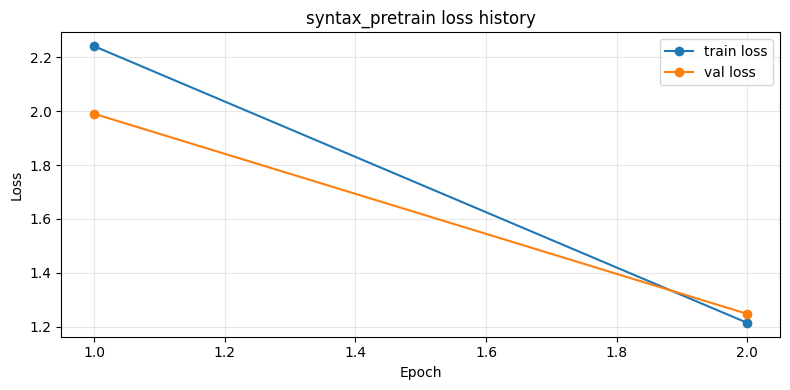

[syntax_pretrain] Epoch 003/005 start
syntax_pretrain train 3/5 [============================] 500/500 100.0% loss=0.9455 avg=0.9940 step=00:00 eta=00:00
syntax_pretrain val 3/5 [============================] 100/100 100.0% loss=1.1253 avg=1.1956 step=00:00 eta=00:00
[syntax_pretrain] Epoch 003 done | train_loss=0.9940 val_loss=1.1956
[syntax_pretrain] Saved new best checkpoint: C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\best_maskrcnn_syntax_pretrain.pt


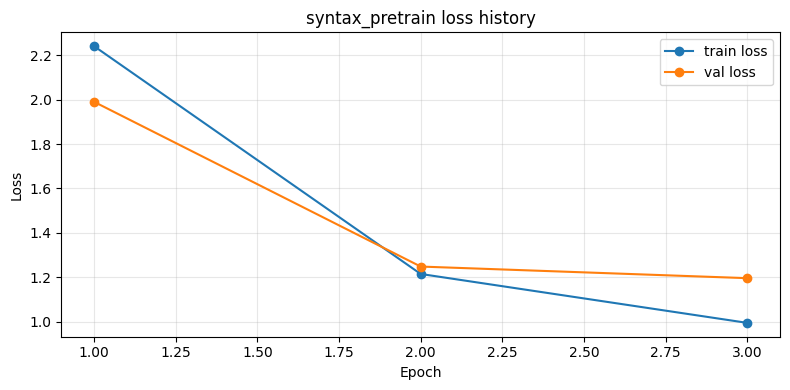

[syntax_pretrain] Epoch 004/005 start
syntax_pretrain train 4/5 [============================] 500/500 100.0% loss=0.7764 avg=0.8863 step=00:00 eta=00:00
syntax_pretrain val 4/5 [============================] 100/100 100.0% loss=1.2569 avg=1.1465 step=00:00 eta=00:00
[syntax_pretrain] Epoch 004 done | train_loss=0.8863 val_loss=1.1465
[syntax_pretrain] Saved new best checkpoint: C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\best_maskrcnn_syntax_pretrain.pt


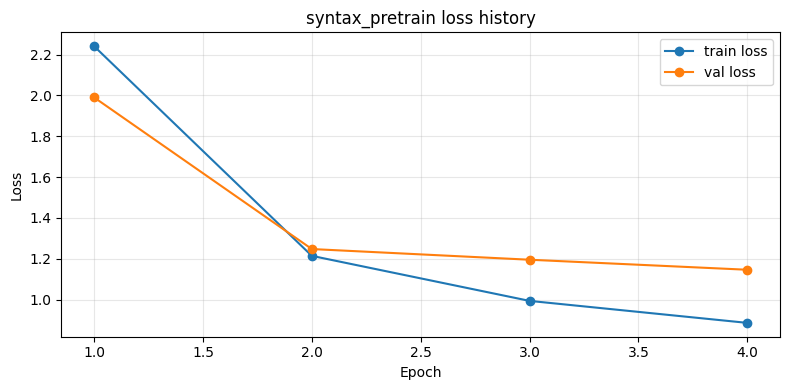

[syntax_pretrain] Epoch 005/005 start
syntax_pretrain train 5/5 [============================] 500/500 100.0% loss=0.7082 avg=0.8158 step=00:00 eta=00:00
syntax_pretrain val 5/5 [============================] 100/100 100.0% loss=1.3055 avg=1.1523 step=00:00 eta=00:00
[syntax_pretrain] Epoch 005 done | train_loss=0.8158 val_loss=1.1523


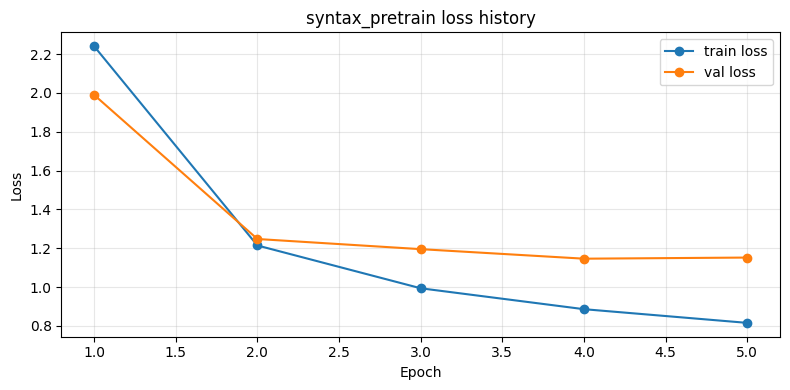

Transferred 301 tensors; skipped 6 task-head tensors.
[stenosis_finetune] Resuming from C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\latest_maskrcnn_stenosis.pt at epoch 3.
[stenosis_finetune] Epoch 003/015 start
stenosis_finetune train 3/15 [============================] 500/500 100.0% loss=0.6165 avg=0.5975 step=00:00 eta=00:00
stenosis_finetune val 3/15 [============================] 100/100 100.0% loss=0.6858 avg=0.6312 step=00:00 eta=00:00
[stenosis_finetune] Epoch 003 done | train_loss=0.5975 val_loss=0.6312
[stenosis_finetune] Saved new best checkpoint: C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\best_maskrcnn_stenosis.pt


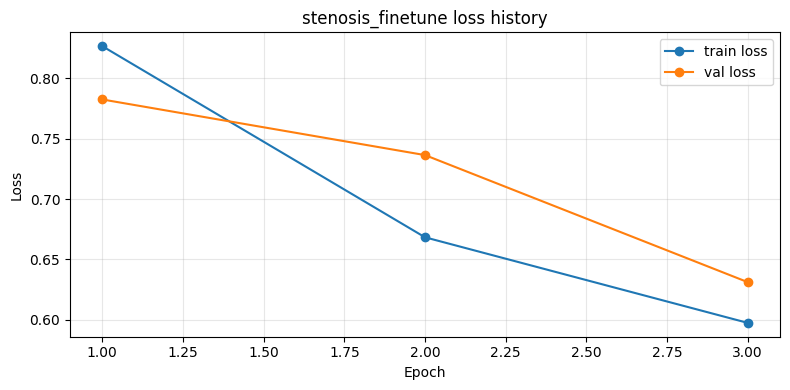

[stenosis_finetune] Epoch 004/015 start
stenosis_finetune train 4/15 [============================] 500/500 100.0% loss=0.5470 avg=0.5376 step=00:00 eta=00:00
stenosis_finetune val 4/15 [============================] 100/100 100.0% loss=0.6402 avg=0.5880 step=00:00 eta=00:00
[stenosis_finetune] Epoch 004 done | train_loss=0.5376 val_loss=0.5880
[stenosis_finetune] Saved new best checkpoint: C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\best_maskrcnn_stenosis.pt


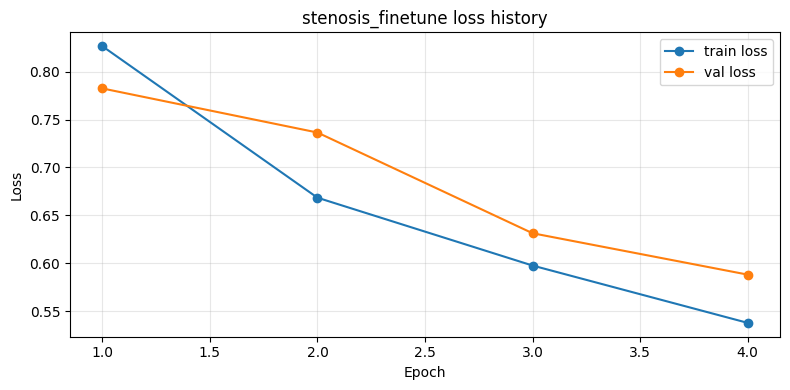

[stenosis_finetune] Epoch 005/015 start
stenosis_finetune train 5/15 [============================] 500/500 100.0% loss=0.6004 avg=0.4987 step=00:00 eta=00:00
stenosis_finetune val 5/15 [============================] 100/100 100.0% loss=0.6861 avg=0.5815 step=00:00 eta=00:00
[stenosis_finetune] Epoch 005 done | train_loss=0.4987 val_loss=0.5815
[stenosis_finetune] Saved new best checkpoint: C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\best_maskrcnn_stenosis.pt


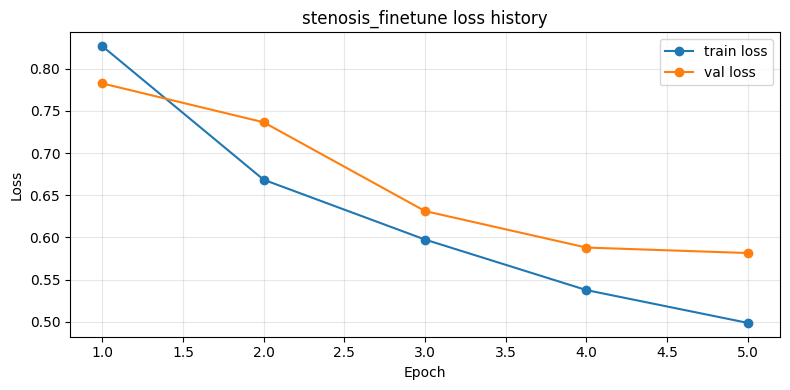

[stenosis_finetune] Epoch 006/015 start
stenosis_finetune train 6/15 [============================] 500/500 100.0% loss=0.4106 avg=0.4759 step=00:00 eta=00:00
stenosis_finetune val 6/15 [============================] 100/100 100.0% loss=0.6912 avg=0.5847 step=00:00 eta=00:00
[stenosis_finetune] Epoch 006 done | train_loss=0.4759 val_loss=0.5847


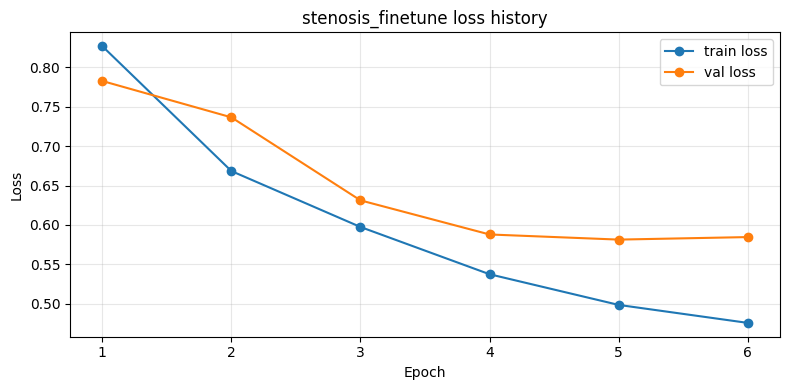

[stenosis_finetune] Epoch 007/015 start
stenosis_finetune train 7/15 [============================] 500/500 100.0% loss=0.6132 avg=0.4609 step=00:00 eta=00:00
stenosis_finetune val 7/15 [============================] 100/100 100.0% loss=0.8063 avg=0.6015 step=00:00 eta=00:00
[stenosis_finetune] Epoch 007 done | train_loss=0.4609 val_loss=0.6015


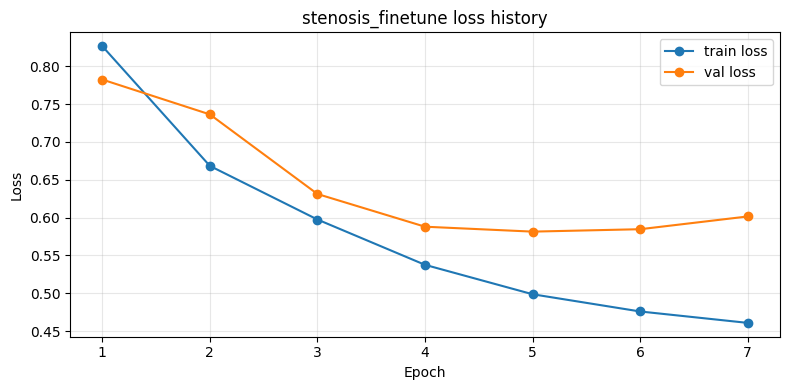

[stenosis_finetune] Epoch 008/015 start
stenosis_finetune train 8/15 [============================] 500/500 100.0% loss=0.4426 avg=0.3993 step=00:00 eta=00:00
stenosis_finetune val 8/15 [============================] 100/100 100.0% loss=0.6848 avg=0.5793 step=00:00 eta=00:00
[stenosis_finetune] Epoch 008 done | train_loss=0.3993 val_loss=0.5793
[stenosis_finetune] Saved new best checkpoint: C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\best_maskrcnn_stenosis.pt


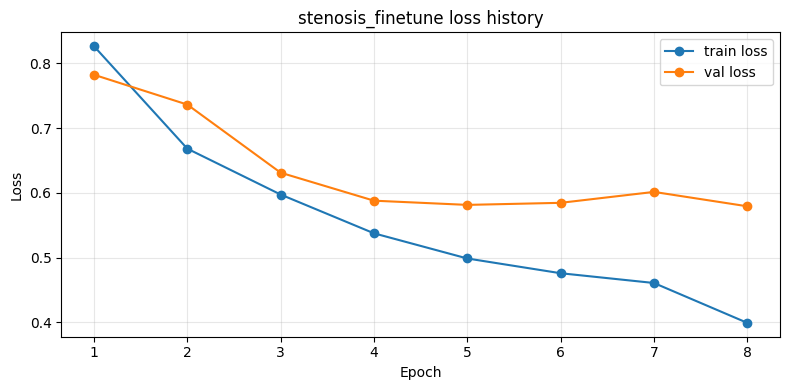

[stenosis_finetune] Epoch 009/015 start
stenosis_finetune train 9/15 [============================] 500/500 100.0% loss=0.2780 avg=0.3623 step=00:00 eta=00:00
stenosis_finetune val 9/15 [============================] 100/100 100.0% loss=0.7891 avg=0.6166 step=00:00 eta=00:00
[stenosis_finetune] Epoch 009 done | train_loss=0.3623 val_loss=0.6166


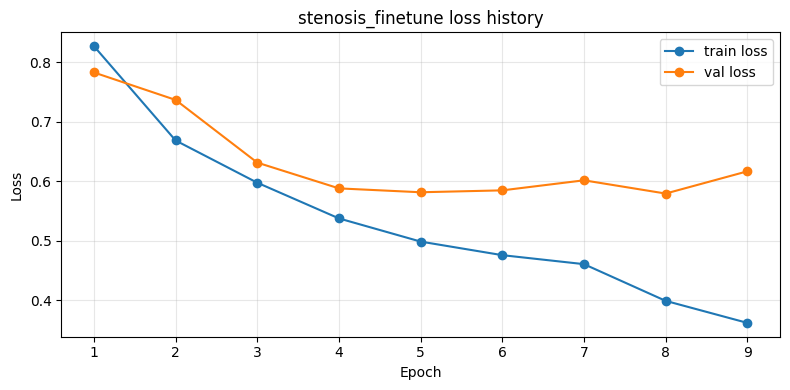

[stenosis_finetune] Epoch 010/015 start
stenosis_finetune train 10/15 [============================] 500/500 100.0% loss=0.2287 avg=0.3382 step=00:00 eta=00:00
stenosis_finetune val 10/15 [============================] 100/100 100.0% loss=0.7854 avg=0.6732 step=00:00 eta=00:00
[stenosis_finetune] Epoch 010 done | train_loss=0.3382 val_loss=0.6732


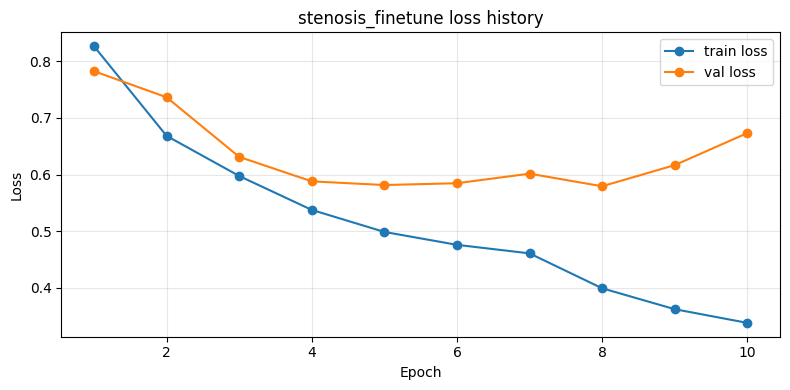

[stenosis_finetune] Epoch 011/015 start
stenosis_finetune train 11/15 [============================] 500/500 100.0% loss=0.2307 avg=0.3146 step=00:00 eta=00:00
stenosis_finetune val 11/15 [============================] 100/100 100.0% loss=0.7617 avg=0.6837 step=00:00 eta=00:00
[stenosis_finetune] Epoch 011 done | train_loss=0.3146 val_loss=0.6837


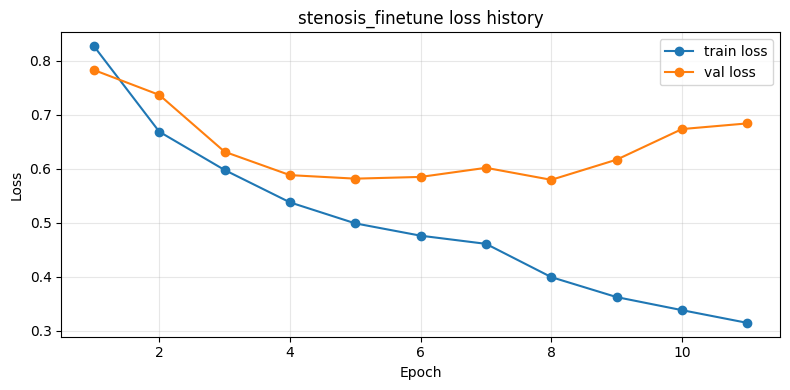

[stenosis_finetune] Epoch 012/015 start
stenosis_finetune train 12/15 [============================] 500/500 100.0% loss=0.4023 avg=0.2950 step=00:00 eta=00:00
stenosis_finetune val 12/15 [============================] 100/100 100.0% loss=0.8369 avg=0.6975 step=00:00 eta=00:00
[stenosis_finetune] Epoch 012 done | train_loss=0.2950 val_loss=0.6975


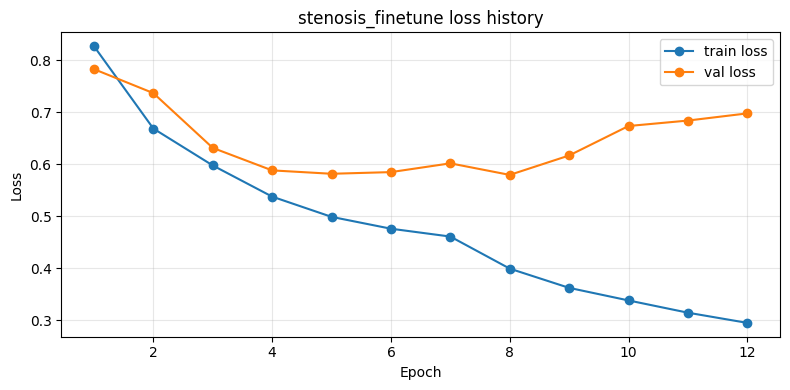

[stenosis_finetune] Epoch 013/015 start
stenosis_finetune train 13/15 [============================] 500/500 100.0% loss=0.2628 avg=0.2564 step=00:00 eta=00:00
stenosis_finetune val 13/15 [============================] 100/100 100.0% loss=0.8330 avg=0.7131 step=00:00 eta=00:00
[stenosis_finetune] Epoch 013 done | train_loss=0.2564 val_loss=0.7131


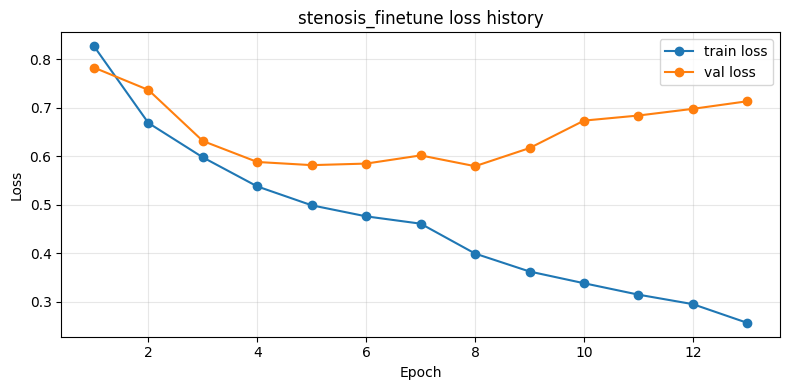

[stenosis_finetune] Epoch 014/015 start
stenosis_finetune train 14/15 [============================] 500/500 100.0% loss=0.4699 avg=0.2344 step=00:00 eta=00:00
stenosis_finetune val 14/15 [============================] 100/100 100.0% loss=0.8918 avg=0.7444 step=00:00 eta=00:00
[stenosis_finetune] Epoch 014 done | train_loss=0.2344 val_loss=0.7444


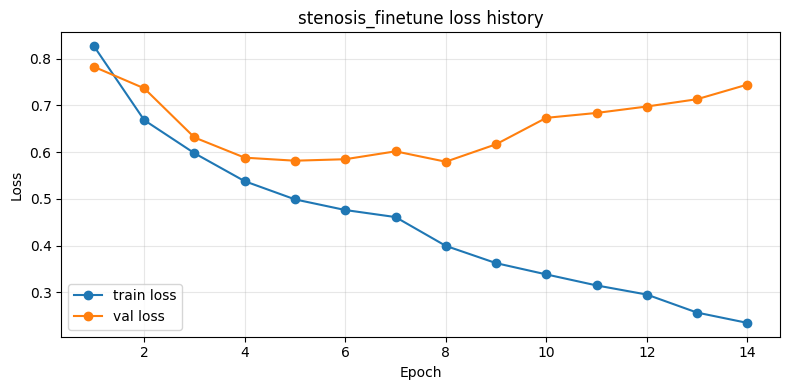

[stenosis_finetune] Epoch 015/015 start
stenosis_finetune train 15/15 [============================] 500/500 100.0% loss=0.1577 avg=0.2159 step=00:00 eta=00:00
stenosis_finetune val 15/15 [============================] 100/100 100.0% loss=1.0100 avg=0.7976 step=00:00 eta=00:00
[stenosis_finetune] Epoch 015 done | train_loss=0.2159 val_loss=0.7976


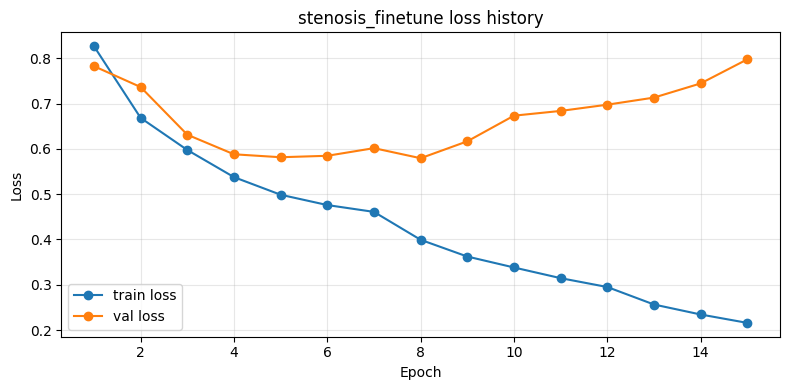

,stage,epoch,train_loss,val_loss
10,stenosis_finetune,6,0.475937,0.584671
11,stenosis_finetune,7,0.460857,0.601528
12,stenosis_finetune,8,0.399258,0.579308
13,stenosis_finetune,9,0.362310,0.616615
14,stenosis_finetune,10,0.338159,0.673217
15,stenosis_finetune,11,0.314601,0.683696
16,stenosis_finetune,12,0.295038,0.697471
17,stenosis_finetune,13,0.256440,0.713108
18,stenosis_finetune,14,0.234412,0.744380
19,stenosis_finetune,15,0.215888,0.797560


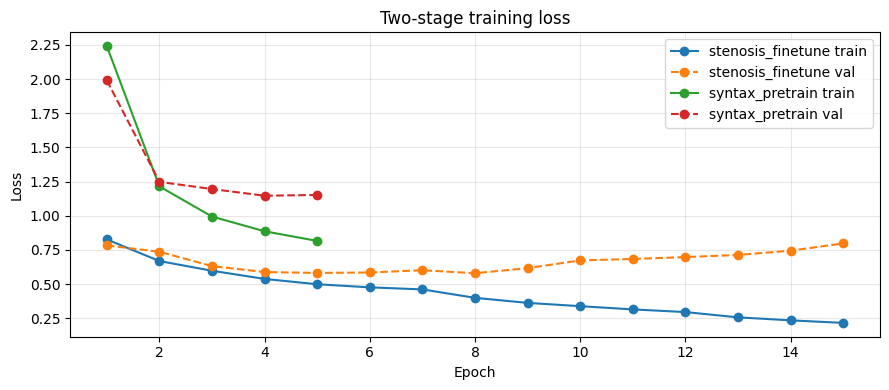

Best stenosis checkpoint: C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\best_maskrcnn_stenosis.pt
Latest stenosis checkpoint: C:\Users\kdkav\Desktop\sorter\rishav\archive\runs\stenosis_localizer\latest_maskrcnn_stenosis.pt


In [9]:
import math
import time

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def format_seconds(seconds):
    if seconds is None or math.isinf(seconds) or math.isnan(seconds):
        return '--:--'
    seconds = int(max(seconds, 0))
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours:
        return f'{hours:d}:{minutes:02d}:{secs:02d}'
    return f'{minutes:02d}:{secs:02d}'


def move_targets_to_device(targets, device):
    moved = []
    for target in targets:
        moved.append({key: value.to(device) for key, value in target.items()})
    return moved


def iter_with_progress(loader, total_steps, description):
    if tqdm is not None:
        return tqdm(loader, total=total_steps, desc=description, leave=True)
    return loader


def run_detection_loss_epoch(model, loader, optimizer=None, max_batches=None, description='train'):
    is_training = optimizer is not None
    model.train()
    total_loss = 0.0
    total_steps = 0
    total_batches = max_batches if max_batches is not None else len(loader)
    started_at = time.time()

    iterator = iter_with_progress(loader, total_batches, description)
    for batch_idx, (images, targets, _paths) in enumerate(iterator, start=1):
        if max_batches is not None and batch_idx > max_batches:
            break

        images = [image.to(device) for image in images]
        targets = move_targets_to_device(targets, device)

        step_started_at = time.time()
        with torch.set_grad_enabled(is_training):
            loss_dict = model(images, targets)
            loss = sum(loss_value for loss_value in loss_dict.values())

        if is_training:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        step_seconds = time.time() - step_started_at
        total_loss += float(loss.detach().cpu())
        total_steps += 1
        avg_loss = total_loss / max(total_steps, 1)
        elapsed = time.time() - started_at
        eta = (elapsed / total_steps) * max(total_batches - total_steps, 0) if total_steps else None

        metrics = {
            'loss': f'{float(loss.detach().cpu()):.4f}',
            'avg': f'{avg_loss:.4f}',
            'step': format_seconds(step_seconds),
            'eta': format_seconds(eta),
        }
        if tqdm is not None and hasattr(iterator, 'set_postfix'):
            iterator.set_postfix(metrics)
        else:
            progress = batch_idx / max(total_batches, 1)
            bar_width = 28
            filled = int(bar_width * progress)
            bar = '=' * filled + '-' * (bar_width - filled)
            message = (
                f"\r{description} [{bar}] {batch_idx}/{total_batches} "
                f"{progress * 100:5.1f}% loss={metrics['loss']} avg={metrics['avg']} "
                f"step={metrics['step']} eta={metrics['eta']}"
            )
            print(message, end='', flush=True)
            if batch_idx == total_batches:
                print()

    return total_loss / max(total_steps, 1)


def plot_stage_history(history, title):
    if not history:
        print(f'No history to plot for {title}.')
        return
    df = pd.DataFrame(history)
    plt.figure(figsize=(8, 4))
    plt.plot(df['epoch'], df['train_loss'], marker='o', label='train loss')
    plt.plot(df['epoch'], df['val_loss'], marker='o', label='val loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def train_stage(stage_name, model, train_loader, val_loader, epochs, max_train_batches, max_val_batches, checkpoint_prefix):
    latest_path = CHECKPOINT_DIR / f'latest_{checkpoint_prefix}.pt'
    best_path = CHECKPOINT_DIR / f'best_{checkpoint_prefix}.pt'

    optimizer = torch.optim.AdamW(model.parameters(), lr=MASKRCNN_LR, weight_decay=MASKRCNN_WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(epochs // 3, 1), gamma=0.5)
    best_val_loss = float('inf')
    history = []
    start_epoch = 1

    if RESUME_FROM_CHECKPOINTS and latest_path.exists():
        checkpoint = torch.load(latest_path, map_location=device)
        model.load_state_dict(checkpoint['model'])
        if 'optimizer' in checkpoint:
            optimizer.load_state_dict(checkpoint['optimizer'])
        if 'scheduler' in checkpoint:
            scheduler.load_state_dict(checkpoint['scheduler'])
        history = checkpoint.get('history', [])
        best_val_loss = checkpoint.get('best_val_loss', best_val_loss)
        start_epoch = int(checkpoint.get('epoch', 0)) + 1
        print(f'[{stage_name}] Resuming from {latest_path} at epoch {start_epoch}.')

    if start_epoch > epochs:
        print(f'[{stage_name}] Already complete: latest epoch {start_epoch - 1}, target epochs {epochs}.')
        plot_stage_history(history, f'{stage_name} loss history')
        return model, history

    for epoch in range(start_epoch, epochs + 1):
        print(f'[{stage_name}] Epoch {epoch:03d}/{epochs:03d} start')
        train_loss = run_detection_loss_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            max_batches=max_train_batches,
            description=f'{stage_name} train {epoch}/{epochs}',
        )
        with torch.no_grad():
            val_loss = run_detection_loss_epoch(
                model,
                val_loader,
                optimizer=None,
                max_batches=max_val_batches,
                description=f'{stage_name} val {epoch}/{epochs}',
            )
        scheduler.step()

        history.append({'stage': stage_name, 'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        print(f'[{stage_name}] Epoch {epoch:03d} done | train_loss={train_loss:.4f} val_loss={val_loss:.4f}')

        checkpoint = {
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'stage': stage_name,
            'epoch': epoch,
            'history': history,
            'best_val_loss': min(best_val_loss, val_loss),
            'stenosis_category_id': STENOSIS_CATEGORY_ID,
            'training_profile': TRAINING_PROFILE,
        }
        torch.save(checkpoint, latest_path)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(checkpoint, best_path)
            print(f'[{stage_name}] Saved new best checkpoint: {best_path}')

        plot_stage_history(history, f'{stage_name} loss history')

    return model, history


print('Training profile:', TRAINING_PROFILE)
print('Device:', device)
print('Batch size:', MASKRCNN_BATCH_SIZE)
print('Syntax epochs:', MASKRCNN_SYNTAX_EPOCHS, '| Stenosis epochs:', MASKRCNN_STENOSIS_EPOCHS)
print('Syntax max batches:', MASKRCNN_MAX_SYNTAX_TRAIN_BATCHES, '| Stenosis max batches:', MASKRCNN_MAX_TRAIN_BATCHES)

syntax_model = build_maskrcnn_model(SYNTAX_NUM_CLASSES, use_coco_pretrained=USE_COCO_PRETRAINED_MASKRCNN).to(device)
syntax_model, syntax_history = train_stage(
    'syntax_pretrain',
    syntax_model,
    syntax_train_loader,
    syntax_val_loader,
    epochs=MASKRCNN_SYNTAX_EPOCHS,
    max_train_batches=MASKRCNN_MAX_SYNTAX_TRAIN_BATCHES,
    max_val_batches=MASKRCNN_MAX_SYNTAX_VAL_BATCHES,
    checkpoint_prefix='maskrcnn_syntax_pretrain',
)

model = build_maskrcnn_model(STENOSIS_NUM_CLASSES, use_coco_pretrained=False).to(device)
model = transfer_matching_weights(syntax_model, model).to(device)
model, stenosis_history = train_stage(
    'stenosis_finetune',
    model,
    train_loader,
    val_loader,
    epochs=MASKRCNN_STENOSIS_EPOCHS,
    max_train_batches=MASKRCNN_MAX_TRAIN_BATCHES,
    max_val_batches=MASKRCNN_MAX_VAL_BATCHES,
    checkpoint_prefix='maskrcnn_stenosis',
)

history_df = pd.DataFrame(syntax_history + stenosis_history)
display(history_df.tail(10))

if not history_df.empty:
    plt.figure(figsize=(9, 4))
    for stage_name, stage_df in history_df.groupby('stage'):
        plt.plot(stage_df['epoch'], stage_df['train_loss'], marker='o', label=f'{stage_name} train')
        plt.plot(stage_df['epoch'], stage_df['val_loss'], marker='o', linestyle='--', label=f'{stage_name} val')
    plt.title('Two-stage training loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

print('Best stenosis checkpoint:', CHECKPOINT_DIR / 'best_maskrcnn_stenosis.pt')
print('Latest stenosis checkpoint:', CHECKPOINT_DIR / 'latest_maskrcnn_stenosis.pt')


## Evaluation and Prediction Overlay

The helper below loads a checkpoint, predicts stenosis masks/boxes, and draws red masks with yellow boxes.


C:\Users\kdkav\AppData\Local\Temp\ipykernel_42548\1504458659.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

Top prediction scores: [0.9128, 0.4399, 0.4004, 0.3548, 0.1053]


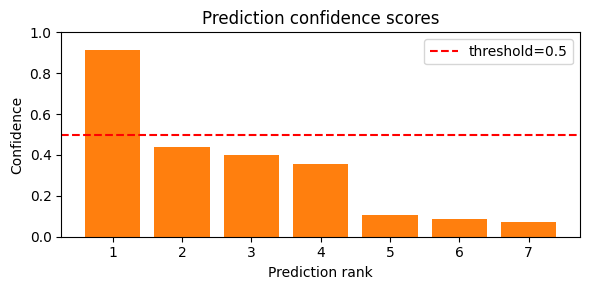

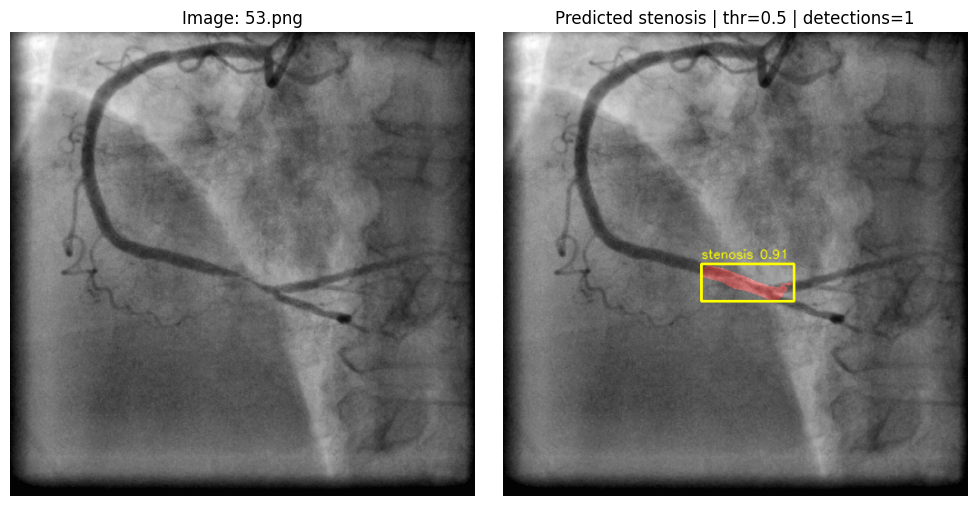

In [25]:
def tensor_to_rgb_image(image_tensor):
    arr = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    arr = np.clip(arr * 255.0, 0, 255).astype(np.uint8)
    return arr


def overlay_mask(rgb, mask, color=(255, 0, 0), alpha=0.35):
    output = rgb.copy()
    color_layer = np.zeros_like(output)
    color_layer[mask] = color
    return cv2.addWeighted(output, 1.0, color_layer, alpha, 0)


def prediction_scores(prediction, top_k=5):
    scores = prediction['scores'].detach().cpu().numpy()
    return [round(float(score), 4) for score in scores[:top_k]]


def plot_prediction_scores(prediction, top_k=10, title='Top prediction scores'):
    scores = prediction['scores'].detach().cpu().numpy()[:top_k]
    if len(scores) == 0:
        print('No prediction scores returned by the model.')
        return
    plt.figure(figsize=(6, 3))
    plt.bar(range(1, len(scores) + 1), scores, color='#ff7f0e')
    plt.axhline(MASKRCNN_SCORE_THRESHOLD, color='red', linestyle='--', label=f'threshold={MASKRCNN_SCORE_THRESHOLD}')
    plt.title(title)
    plt.xlabel('Prediction rank')
    plt.ylabel('Confidence')
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()


def draw_prediction_overlay(rgb, prediction, score_threshold=MASKRCNN_SCORE_THRESHOLD, mask_threshold=0.5, max_detections=5):
    output = rgb.copy()
    boxes = prediction['boxes'].detach().cpu().numpy()
    scores = prediction['scores'].detach().cpu().numpy()
    masks = prediction['masks'].detach().cpu().numpy()

    kept = 0
    for box, score, mask in zip(boxes, scores, masks):
        if score < score_threshold:
            continue
        kept += 1
        if kept > max_detections:
            break
        binary_mask = mask[0] >= mask_threshold
        output = overlay_mask(output, binary_mask, color=(255, 0, 0), alpha=0.35)
        x1, y1, x2, y2 = [int(round(v)) for v in box]
        cv2.rectangle(output, (x1, y1), (x2, y2), (255, 255, 0), 2)
        cv2.putText(output, f'stenosis {score:.2f}', (x1, max(y1 - 6, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1, cv2.LINE_AA)
    return output, kept


def load_maskrcnn_checkpoint(checkpoint_path):
    loaded_model = build_maskrcnn_model(STENOSIS_NUM_CLASSES, use_coco_pretrained=False).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    loaded_model.load_state_dict(checkpoint['model'])
    loaded_model.eval()
    return loaded_model


def load_image_for_prediction(image_path, use_clahe=True):
    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(image_path)
    if use_clahe:
        gray = apply_clahe(gray)
    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    tensor = F.to_tensor(Image.fromarray(rgb))
    return rgb, tensor


def pick_random_test_image_path(dataset_splits=stenosis_splits, split_name='test', stenosis_only=False):
    info = dataset_splits[split_name]
    images = info['coco']['images']
    image_lookup = info['image_lookup']
    anns_lookup = info['anns_lookup']
    img_dir = info['img_dir']

    if stenosis_only:
        candidates = []
        for image_info in images:
            image_id = image_info['id']
            anns = anns_lookup.get(image_id, [])
            if any(int(ann.get('category_id', -1)) == int(STENOSIS_CATEGORY_ID) for ann in anns):
                candidates.append(image_info)
        if not candidates:
            raise ValueError(f'No test images contain stenosis category_id={STENOSIS_CATEGORY_ID}.')
    else:
        candidates = images

    chosen = random.choice(candidates)
    chosen_path = img_dir / image_lookup[chosen['id']]
    return chosen_path


def predict_and_show(image_path=None, checkpoint_path=CHECKPOINT_DIR / 'best_maskrcnn_stenosis.pt', threshold=MASKRCNN_SCORE_THRESHOLD, random_test_if_none=True, stenosis_only_random=False):
    if image_path is None:
        if not random_test_if_none:
            raise ValueError('Pass image_path or set random_test_if_none=True.')
        image_path = pick_random_test_image_path(stenosis_splits, split_name='test', stenosis_only=stenosis_only_random)
        print(f'Random test image selected: {image_path}')

    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}. Run the training cell first.')

    inference_model = load_maskrcnn_checkpoint(checkpoint_path)
    rgb, tensor = load_image_for_prediction(image_path, use_clahe=True)

    with torch.no_grad():
        prediction = inference_model([tensor.to(device)])[0]

    print('Top prediction scores:', prediction_scores(prediction))
    plot_prediction_scores(prediction, title='Prediction confidence scores')
    overlay, kept = draw_prediction_overlay(rgb, prediction, score_threshold=threshold)
    display_threshold = threshold
    if kept == 0:
        print(f'No confident detections at threshold={threshold}. Do not trust lower-threshold boxes as final predictions.')

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title(f'Image: {Path(image_path).name}')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f'Predicted stenosis | thr={display_threshold} | detections={kept}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return prediction


# Example: random test image prediction from test split.
PATH_TEST = r"C:\Users\kdkav\Desktop\sorter\rishav\archive\data\syntax\test\images\53.png"
_ = predict_and_show(image_path=PATH_TEST, random_test_if_none=True, stenosis_only_random=False)


## Ground Truth vs Prediction Demo

This cell compares the annotation mask with the trained model prediction on one test image.


C:\Users\kdkav\AppData\Local\Temp\ipykernel_42548\3480143794.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

Train sanity |  top prediction scores: [0.971, 0.4602, 0.3008, 0.2959, 0.133]


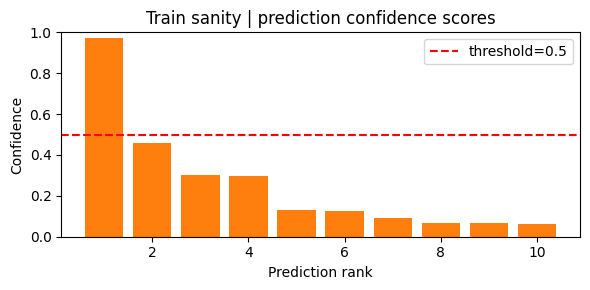

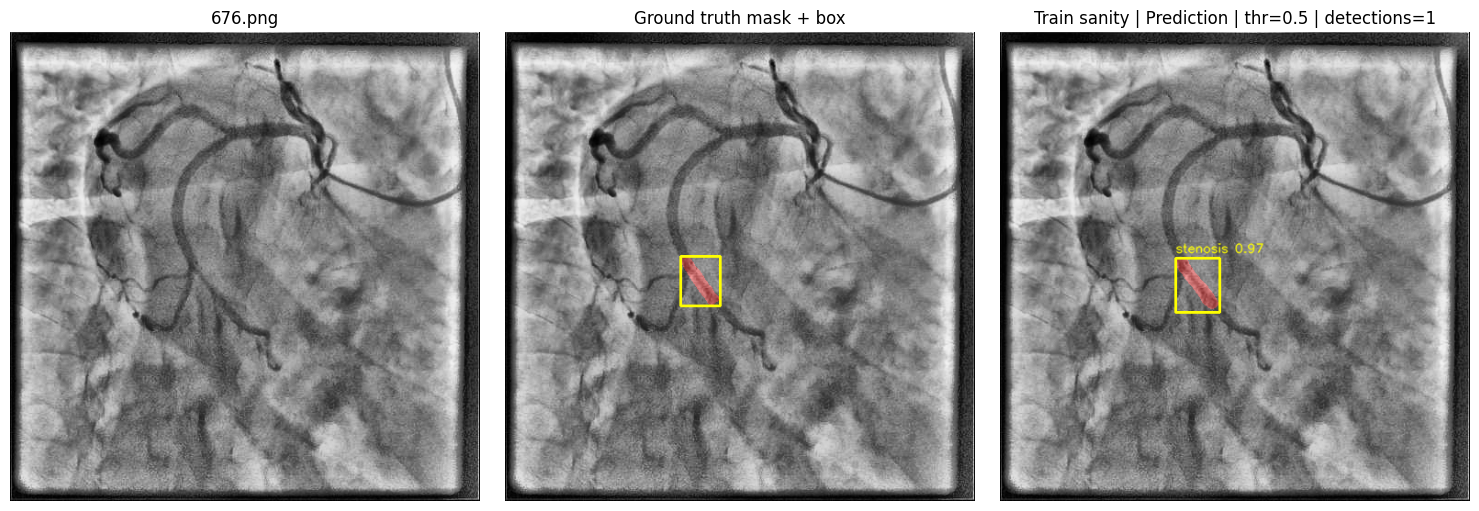

Test |  top prediction scores: [0.9025, 0.8259, 0.6574, 0.4915, 0.3375]


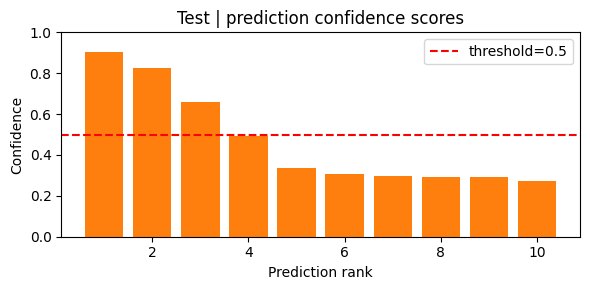

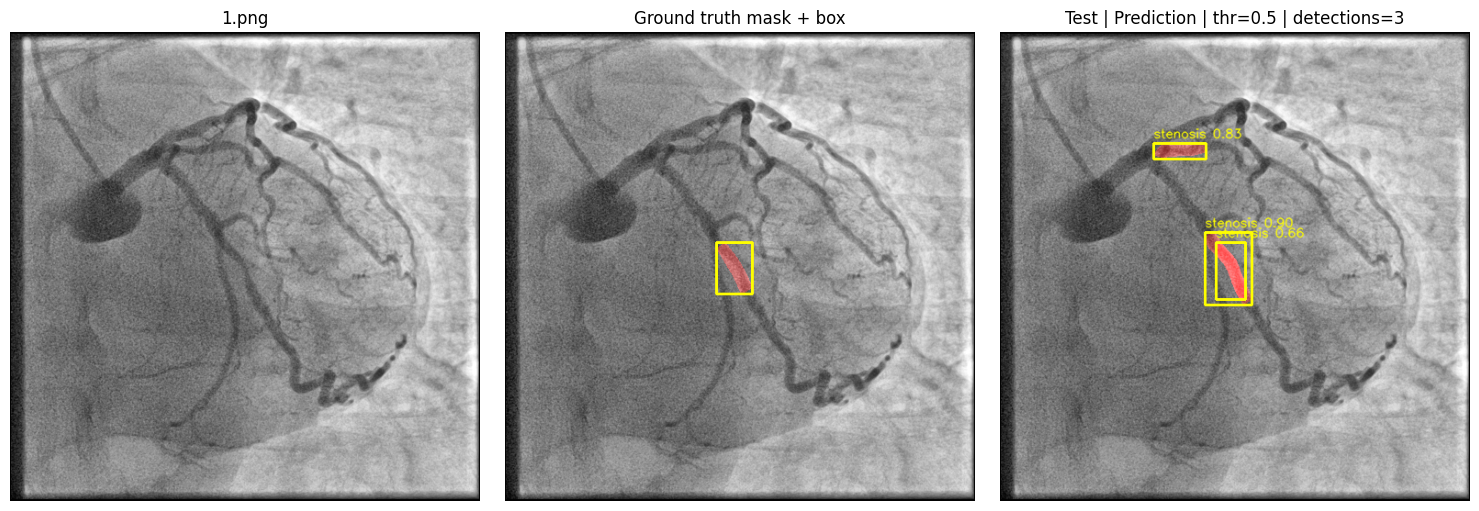

In [19]:
def show_ground_truth_vs_prediction(dataset, index=0, checkpoint_path=CHECKPOINT_DIR / 'best_maskrcnn_stenosis.pt', threshold=MASKRCNN_SCORE_THRESHOLD, title_prefix=''):
    image_tensor, target, image_path = dataset[index]
    rgb = tensor_to_rgb_image(image_tensor)

    gt_overlay = rgb.copy()
    for mask in target['masks']:
        gt_overlay = overlay_mask(gt_overlay, mask.detach().cpu().numpy().astype(bool), color=(255, 0, 0), alpha=0.35)
    for box in target['boxes'].detach().cpu().numpy():
        x1, y1, x2, y2 = [int(round(v)) for v in box]
        cv2.rectangle(gt_overlay, (x1, y1), (x2, y2), (255, 255, 0), 2)

    if Path(checkpoint_path).exists():
        inference_model = load_maskrcnn_checkpoint(checkpoint_path)
        with torch.no_grad():
            prediction = inference_model([image_tensor.to(device)])[0]
        print(f'{title_prefix} top prediction scores:', prediction_scores(prediction))
        plot_prediction_scores(prediction, title=f'{title_prefix}prediction confidence scores')
        pred_overlay, kept = draw_prediction_overlay(rgb, prediction, score_threshold=threshold)
        if kept == 0:
            print(f'{title_prefix} no confident detections at threshold={threshold}.')
        pred_title = f'{title_prefix}Prediction | thr={threshold} | detections={kept}'
    else:
        pred_overlay = rgb
        pred_title = 'Prediction skipped: train first'

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title(Path(image_path).name)
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(gt_overlay)
    plt.title('Ground truth mask + box')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(pred_overlay)
    plt.title(pred_title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# First check a train image. If this is bad, the model has not learned enough yet.
show_ground_truth_vs_prediction(train_dataset, index=0, threshold=0.5, title_prefix='Train sanity | ')

# Then check a held-out test image.
show_ground_truth_vs_prediction(test_dataset, index=0, threshold=0.5, title_prefix='Test | ')
